In [18]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.neural_network import MLPClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
print("✅ 라이브러리 로딩 완료!")

✅ 라이브러리 로딩 완료!


In [19]:
# 1. 데이터 불러오기 (파일 경로 확인)
file_path = 'Telco_customer_churn - Telco_Churn.csv'
df = pd.read_csv(file_path)

# 2. Total Charges(총 청구 요금) 결측치 처리
df['Total Charges'] = pd.to_numeric(df['Total Charges'].replace(' ', np.nan))
df['Total Charges'] = df['Total Charges'].fillna(0)

print(f"✅ 원본 데이터 크기: {df.shape}")

✅ 원본 데이터 크기: (7043, 33)


In [ ]:

services = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

# Total_Services: 가입한 부가서비스 총 개수 (0~6개).
# 의미: 락인(Lock-in) 효과 측정. 많이 가입할수록 이탈률 하락.
df['Total_Services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Extra_Charges: 총 누적 요금에서 (월 요금 × 가입 개월 수)를 뺀 숨겨진 추가 요금.
# 의미: 요금 폭탄이나 연체료 등으로 인한 불만 발생 여부 포착.
df['Extra_Charges'] = df['Total Charges'] - (df['Monthly Charges'] * df['Tenure Months'])

# Price_per_Service: (월 요금 / (부가서비스 수 + 1)). 서비스 1개당 체감 단가.
# 의미: 가성비 지표. 혜택은 없는데 요금만 비싸면 이탈 확률 상승.
df['Price_per_Service'] = df['Monthly Charges'] / (df['Total_Services'] + 1)

# Full_Family: 배우자와 부양가족이 모두 있는 고객 (1/0).
# 의미: 가족 결합 할인으로 단단히 묶여 있는 가장 안전한 고객군.
df['Full_Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)

# Single_Senior: 배우자와 부양가족이 없는 65세 이상 1인 가구 (1/0).
# 의미: 요금에 민감하고 기술 문제 해결에 취약한 특정 타겟
df['Single_Senior'] = ((df['Senior Citizen'] == 'Yes') & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)

# Auto_Payment: 자동 결제(신용카드/은행) 등록 여부 (1/0).
# 의미: 매달 청구서를 직접 내는 귀찮음과 요금 체감을 줄여주는 이탈 방어막.
df['Auto_Payment'] = df['Payment Method'].str.contains('automatic').astype(int)

# --- [신규 페르소나 피처 3종] ---
# 1. 속도 불만/경쟁사 이동 위험군 (광랜 + 무약정 + 6~24개월 차)
df['Speed_Competitor_Risk'] = (
    (df['Internet Service'] == 'Fiber optic') & 
    (df['Contract'] == 'Month-to-month') & 
    (df['Tenure Months'] >= 6) & (df['Tenure Months'] <= 24)
).astype(int)

# 2. 가격 민감형 위험군 (평균 요금 이상 + 무약정 + 1인 가구)
median_charge = df['Monthly Charges'].median()
df['Price_Sensitive_Risk'] = (
    (df['Monthly Charges'] > median_charge) & 
    (df['Contract'] == 'Month-to-month') & 
    (df['Dependents'] == 'No')
).astype(int)

# 3. 서비스/제품 불만족 위험군 (기술지원 없음 + 보안 없음 + 인터넷 사용)
df['Tech_Lacking_Risk'] = (
    (df['Tech Support'] == 'No') & 
    (df['Online Security'] == 'No') &
    (df['Internet Service'] != 'No')
).astype(int)

print(f"✅ 총 9개의 파생 변수 추가 완료! 현재 데이터 크기: {df.shape}")

✅ 총 9개의 파생 변수 추가 완료! 현재 데이터 크기: (7043, 42)


📊 ['Churn Label'과 'Churn Score'를 제외한 순수 상관관계 분석을 시작합니다...]


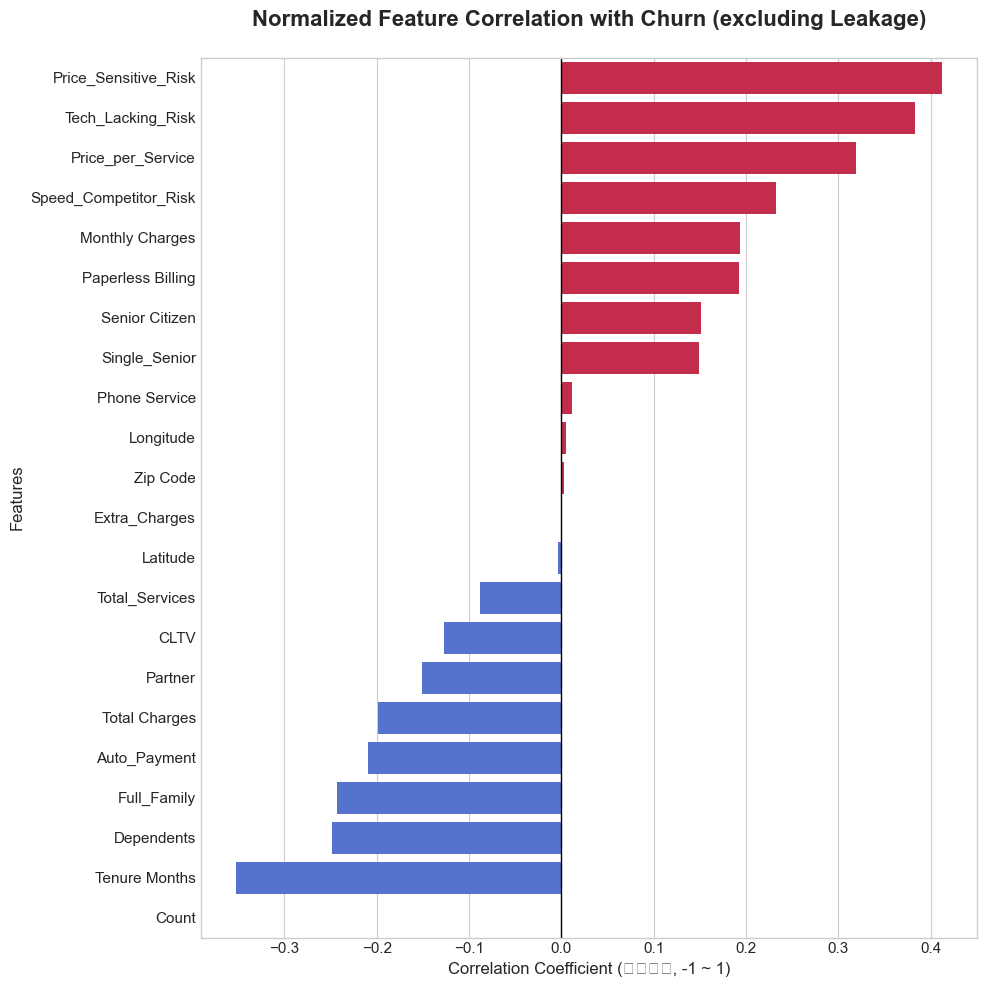


🔥 Churn(이탈)을 부추기는 위험 변수 Top 5:
Price_Sensitive_Risk     0.411827
Tech_Lacking_Risk        0.382979
Price_per_Service        0.319316
Speed_Competitor_Risk    0.232115
Monthly Charges          0.193356
Name: Churn Value, dtype: float64

❄️ Churn(이탈)을 막아주는 안전 변수 Top 5:
Auto_Payment    -0.209902
Full_Family     -0.243241
Dependents      -0.248542
Tenure Months   -0.352229
Count                 NaN
Name: Churn Value, dtype: float64


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 ['Churn Label'과 'Churn Score'를 제외한 순수 상관관계 분석을 시작합니다...]")

# 1. 숫자형 및 이진형(1/0) 데이터만 선택
numeric_df = df.select_dtypes(include=['number', 'bool'])

# (안전장치) Churn Value가 문자열 형태라면 숫자로 변환
if numeric_df['Churn Value'].dtype == 'object':
    numeric_df['Churn Value'] = numeric_df['Churn Value'].astype(int)

# 2. 제외할 중복/누수 컬럼 리스트 정의
# Churn Value는 우리의 기준점이므로 남겨두고, 나머지 정답 노출 컬럼을 제외합니다.
# (원본 데이터에 따라 Churn Score나 Churn Label 등의 대소문자를 확인해 주세요)
leakage_cols = ['Churn Score', 'Churn Label']
leakage_cols = [col for col in leakage_cols if col in numeric_df.columns] # 존재하는 컬럼만 선택

# 3. 누수 컬럼 제거 후 Churn Value와의 상관계수 계산 및 정렬
churn_corr = numeric_df.drop(columns=leakage_cols).corr()['Churn Value'].drop('Churn Value')
churn_corr = churn_corr.sort_values(ascending=False)

# 4. 시각화 (막대 차트)
plt.figure(figsize=(10, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# 양의 상관관계(빨간색/위험)와 음의 상관관계(파란색/안전) 색상 구분
# (상관계수 자체가 -1 ~ 1로 정규화된 지표입니다)
colors = ['crimson' if x > 0 else 'royalblue' for x in churn_corr.values]

sns.barplot(x=churn_corr.values, y=churn_corr.index, palette=colors)
plt.title('Normalized Feature Correlation with Churn (excluding Leakage)\n', fontweight='bold', fontsize=16)
plt.xlabel('Correlation Coefficient (상관계수, -1 ~ 1)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 가운데 0을 기준으로 선 긋기
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

# 5. 상관관계 상위 5개와 하위 5개를 표로 출력하여 정확한 수치 확인
print("\n🔥 Churn(이탈)을 부추기는 위험 변수 Top 5:")
print(churn_corr.head(5))
print("\n❄️ Churn(이탈)을 막아주는 안전 변수 Top 5:")
print(churn_corr.tail(5))

In [21]:
print("🛠️ 'Yes'/'No' 이진 데이터 변환을 시작합니다...")

binary_cols = []
for col in df.columns:
    unique_values = set(df[col].dropna().unique())
    if unique_values.issubset({'Yes', 'No'}):
        binary_cols.append(col)

# Yes는 1, No는 0으로 매핑
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(f"✅ 1과 0으로 변환 완료된 컬럼: {binary_cols}")

🛠️ 'Yes'/'No' 이진 데이터 변환을 시작합니다...
✅ 1과 0으로 변환 완료된 컬럼: ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Churn Label']


In [22]:
# 1. 제거할 컬럼 리스트 (미래의 정답인 Churn Reason 등 제외)
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 
             'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason']

X = df.drop(columns=drop_cols + ['Churn Value'])
y = df['Churn Value'].values

# 2. 변수 성격에 따른 분류
# 추가된 파생 변수들과 1/0으로 변환된 변수들을 모두 숫자형(numeric)에 포함시킵니다.
numeric_features = [
    'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV',
    'Total_Services', 'Extra_Charges', 'Price_per_Service', 
    'Full_Family', 'Single_Senior', 'Auto_Payment',
    'Speed_Competitor_Risk', 'Price_Sensitive_Risk', 'Tech_Lacking_Risk', # 신규 피처
    'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing' # 변환된 피처
]

# 위 리스트에 없는 나머지 문자열 변수들 (예: 'No internet service'가 포함된 컬럼 등)
categorical_features = [
    'Gender', 'Multiple Lines', 'Internet Service', 'Online Security', 
    'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 
    'Streaming Movies', 'Contract', 'Payment Method'
]

# 3. 전처리 파이프라인
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 4. 데이터 분할 (에러를 해결한 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"✅ 전처리 완료! 학습 데이터 형태: {X_train_processed.shape}")

✅ 전처리 완료! 학습 데이터 형태: (5634, 51)


In [23]:
# 재현율(Recall)을 극대화하기 위해 이탈자 데이터를 0.5 비율까지만 증폭합니다.
print("📊 SMOTE 적용 전 클래스 분포:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("\n🚀 SMOTE 적용 후 클래스 분포:")
print(pd.Series(y_train_resampled).value_counts())

📊 SMOTE 적용 전 클래스 분포:
0    4139
1    1495
Name: count, dtype: int64

🚀 SMOTE 적용 후 클래스 분포:
0    4139
1    2069
Name: count, dtype: int64


In [24]:
# 1. MLP 모델
print("🚀 [1/3] MLP 모델 학습 중...")
mlp_model = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500, random_state=42, early_stopping=True)
mlp_model.fit(X_train_resampled, y_train_resampled)
mlp_probs = mlp_model.predict_proba(X_test_processed)[:, 1]

# 2. TabNet 모델
print("🚀 [2/3] TabNet 모델 학습 중...")
tabnet_model = TabNetClassifier(verbose=0, seed=42)
tabnet_model.fit(
    X_train=X_train_resampled, y_train=y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled), (X_test_processed, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],
    max_epochs=100, patience=15
)
tabnet_probs = tabnet_model.predict_proba(X_test_processed)[:, 1]

# 3. LightGBM 모델
print("🚀 [3/3] LightGBM 모델 학습 중...")
lgbm_model = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
lgbm_model.fit(X_train_resampled, y_train_resampled)
lgbm_probs = lgbm_model.predict_proba(X_test_processed)[:, 1]

print("✅ 모든 모델 학습 완료!")

🚀 [1/3] MLP 모델 학습 중...
🚀 [2/3] TabNet 모델 학습 중...

Early stopping occurred at epoch 46 with best_epoch = 31 and best_valid_auc = 0.84747
🚀 [3/3] LightGBM 모델 학습 중...
✅ 모든 모델 학습 완료!


In [25]:
# LightGBM에 가중치를 가장 많이 주는 황금 비율 적용
w_mlp = 0.2
w_tabnet = 0.2
w_lgbm = 0.6

# 확률 가중합산
ensemble_probs = (mlp_probs * w_mlp) + (tabnet_probs * w_tabnet) + (lgbm_probs * w_lgbm)
ensemble_preds = (ensemble_probs >= 0.5).astype(int) 

# 결과 출력
print("="*50)
print(" 🏆 [MLP + TabNet + LightGBM] 최종 앙상블 성능 🏆")
print("="*50)
print(f"▶ ROC AUC Score: {roc_auc_score(y_test, ensemble_probs):.4f}")
print("-" * 50)
print(classification_report(y_test, ensemble_preds))

 🏆 [MLP + TabNet + LightGBM] 최종 앙상블 성능 🏆
▶ ROC AUC Score: 0.8551
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1035
           1       0.62      0.60      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.79      1409



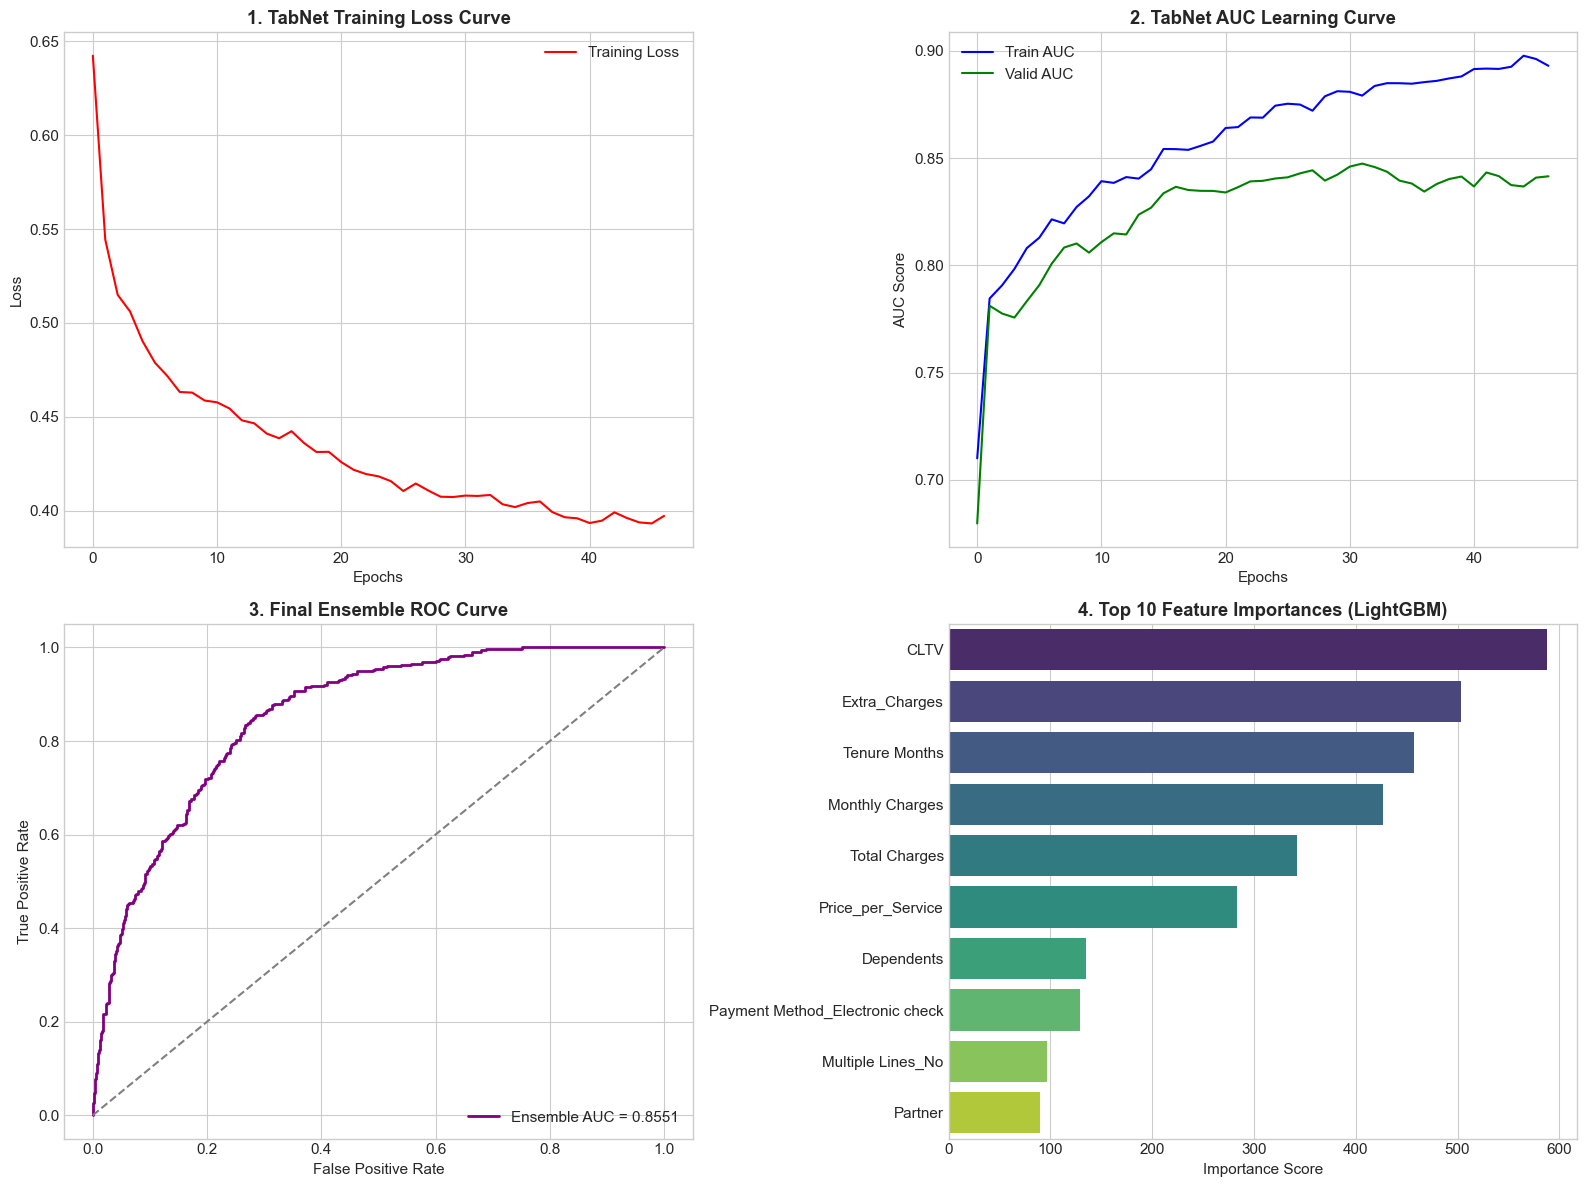

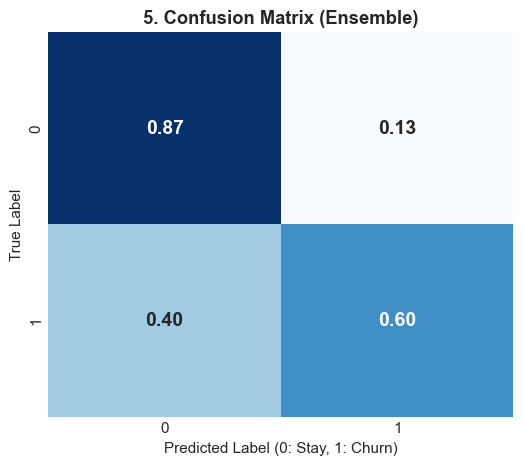

In [26]:
# [Cell 9] 모델 시각화 대시보드
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# 한글 폰트가 깨질 수 있으므로 기본 영문 설정 유지 및 스타일 지정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

fig = plt.figure(figsize=(16, 12))

# -----------------------------------------------------------
# 1. TabNet 학습 곡선 (Loss & AUC)
# -----------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
ax1.plot(tabnet_model.history['loss'], color='red', label='Training Loss')
ax1.set_title('1. TabNet Training Loss Curve', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2 = plt.subplot(2, 2, 2)
ax2.plot(tabnet_model.history['train_auc'], label='Train AUC', color='blue')
ax2.plot(tabnet_model.history['valid_auc'], label='Valid AUC', color='green')
ax2.set_title('2. TabNet AUC Learning Curve', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('AUC Score')
ax2.legend()

# -----------------------------------------------------------
# 3. 앙상블 모델 ROC Curve
# -----------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
auc_score = roc_auc_score(y_test, ensemble_probs)

ax3.plot(fpr, tpr, color='purple', linewidth=2, label=f'Ensemble AUC = {auc_score:.4f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('3. Final Ensemble ROC Curve', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(loc='lower right')

# -----------------------------------------------------------
# 4. LightGBM 변수 중요도 (Feature Importance) - Top 10
# -----------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)

# 전처리 파이프라인에서 생성된 변수 이름들 가져오기
feature_names = preprocessor.get_feature_names_out()
importances = lgbm_model.feature_importances_

# 중요도 순으로 정렬하여 데이터프레임 생성
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# 변수 이름 깔끔하게 정리 (예: num__Tenure Months -> Tenure Months)
importance_df['Feature'] = importance_df['Feature'].str.split('__').str[-1]

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax4)
ax4.set_title('4. Top 10 Feature Importances (LightGBM)', fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 5. 혼동 행렬 (Confusion Matrix)
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix

# 1. confusion_matrix 생성 시 normalize='true' 옵션 사용 (행 기준 정규화)
# 또는 'all', 'pred' 등 목적에 맞게 설정 가능합니다.
cm = confusion_matrix(y_test, ensemble_preds, normalize='true') 

plt.figure(figsize=(6, 5))

# 2. sns.heatmap에서 'normalize=True' 삭제
# 정규화된 데이터이므로 소수점 표시를 위해 fmt='.2f'로 변경하는 것이 좋습니다.
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False, 
            annot_kws={"size": 14, "weight": "bold"}) 

plt.title('5. Confusion Matrix (Ensemble)', fontweight='bold')
plt.xlabel('Predicted Label (0: Stay, 1: Churn)')
plt.ylabel('True Label') # 실제 라벨 표시 추가 권장
plt.show()

🚀 MLP 수동 학습 및 기록을 시작합니다...
✅ 학습 및 기록 완료! 그래프를 그립니다.


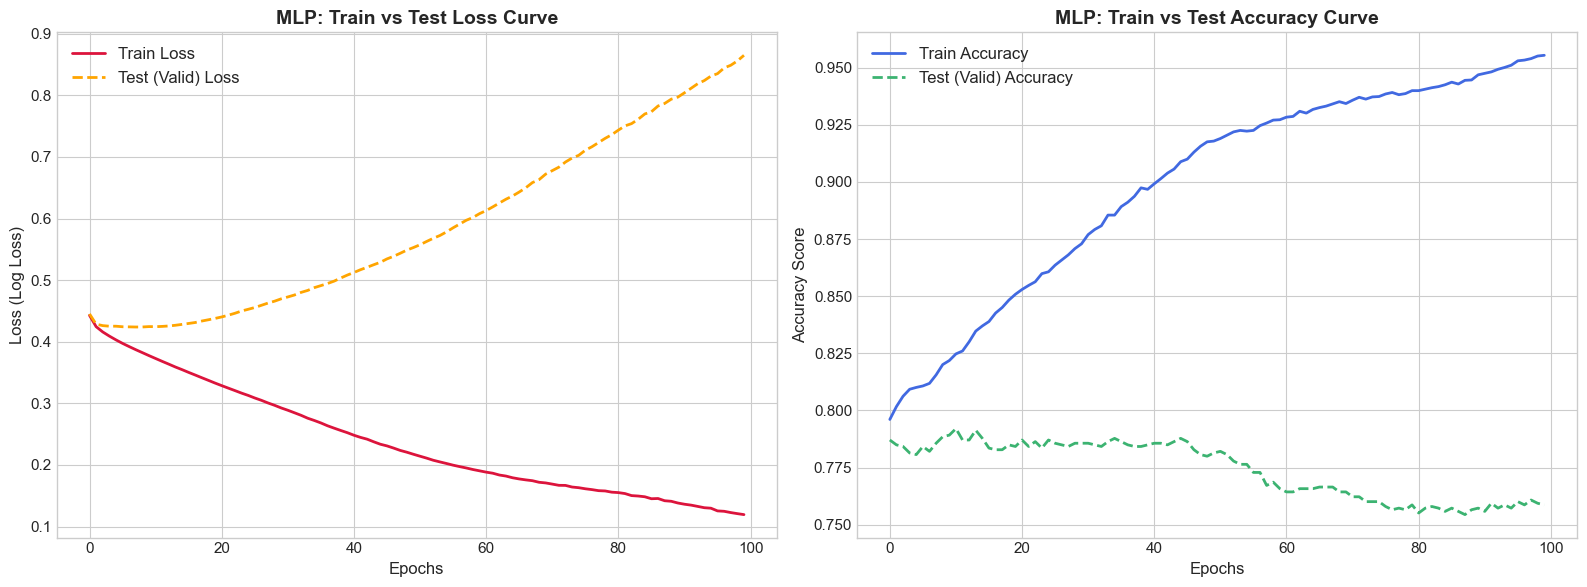

In [27]:
# [Cell 10 대체] MLP 모델 직접 학습시키며 Train / Test 지표 모두 기록하기
from sklearn.metrics import log_loss, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 1. 새로운 MLP 모델 준비
mlp_custom = MLPClassifier(hidden_layer_sizes=(128, 64), random_state=42)
classes = np.unique(y_train_resampled)

# 2. 기록장 준비
epochs = 100 # 최대 100번 반복
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("🚀 MLP 수동 학습 및 기록을 시작합니다...")

# 3. 한 에포크(Epoch)씩 학습하며 직접 기록
for epoch in range(epochs):
    # 한 스텝 학습
    mlp_custom.partial_fit(X_train_resampled, y_train_resampled, classes=classes)
    
    # 현재 스텝에서의 예측 확률 및 결과
    train_prob = mlp_custom.predict_proba(X_train_resampled)
    test_prob = mlp_custom.predict_proba(X_test_processed)
    train_pred = mlp_custom.predict(X_train_resampled)
    test_pred = mlp_custom.predict(X_test_processed)
    
    # Loss(Log Loss) 기록
    train_losses.append(log_loss(y_train_resampled, train_prob))
    test_losses.append(log_loss(y_test, test_prob))
    
    # Accuracy 기록
    train_accs.append(accuracy_score(y_train_resampled, train_pred))
    test_accs.append(accuracy_score(y_test, test_pred))

print("✅ 학습 및 기록 완료! 그래프를 그립니다.")

# 4. 시각화 (Train vs Test)
plt.figure(figsize=(16, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# [왼쪽 그래프] Train Loss vs Test Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='crimson', linewidth=2)
plt.plot(test_losses, label='Test (Valid) Loss', color='orange', linewidth=2, linestyle='--')
plt.title('MLP: Train vs Test Loss Curve', fontweight='bold', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Log Loss)', fontsize=12)
plt.legend(fontsize=12)

# [오른쪽 그래프] Train Accuracy vs Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', color='royalblue', linewidth=2)
plt.plot(test_accs, label='Test (Valid) Accuracy', color='mediumseagreen', linewidth=2, linestyle='--')
plt.title('MLP: Train vs Test Accuracy Curve', fontweight='bold', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()